In [18]:
'''practice for midsem AIML'''

import heapq
import numpy as np 

In [2]:
## A* algorithm

class Node :
    def __init__(self,config) -> None:
         self.arr = np.array(config)
         self.g = 0
         self.h = 0
    def __lt__(self, other):
        return self.g + self.h < other.g + other.h
    
    def __eq__(self, __value: object) -> bool:
        return np.array_equal(self.arr,__value.arr)
    
    def getNeighbors(self):
        pass

def h(curr: list,final: list):
    return np.abs(final[1]-curr[1]) + np.abs(final[0] - curr[0])

def a_star(grid:np.ndarray,initial:tuple,goal:tuple):
    open=[]
    closed = set()
    path =[]
    parent = dict()
    moves = dict()
    heapq.heappush(open,(h(initial,goal),0,initial)) ## (f_val, g_val, state)
    parent[initial] = -1
    while open:
        _,curr_g,curr = heapq.heappop(open)
        # print(f"node ",curr)
        if str(curr) in closed:
            continue
        closed.add(str(curr))
        if(curr == goal):
            ## do something
            while(parent[curr]!=-1):
                path.append(moves[curr])
                curr = parent[curr]
            path.reverse()
            return path
        
        for move,(dx,dy) in { 'U':(0,-1), 'D':(0,1), 'R':(1,0), 'L':(-1,0)}.items():
            new_x , new_y = curr[0]+dx,curr[1]+dy
            
            if(0<=new_x<len(grid[0]) and 0<=new_y<len(grid)):
                
                if(grid[new_y][new_x] == 1):
                    continue
            
                new_state = (new_x,new_y)
                if(str(new_state) in closed):
                    continue
                parent[new_state] = curr
                moves[new_state] = move
                heapq.heappush(open,(curr_g+1+h(new_state,goal),curr_g+1,new_state))
    return -1


In [21]:
grid = [
    [0, 0, 0, 0, 1],
    [0, 1, 1, 1, 1],
    [0, 1, 0, 0, 0],
    [0, 1, 0, 1, 1],
    [0, 0, 0, 1, 0]
]
start = (0,0)
goal =(4,4)

print(a_star(grid,start,goal))

-1


In [3]:
## perceptron training algorithm

x = np.array([
    [1,1],
    [1,0],
    [0,1],
    [0,0]
])
y = np.array(
   [[0],
    [1],
    [1],
    [0]]
)

def preprocessing(x,y):
    x = np.hstack((x,-np.ones((x.shape[0],1))))
    x = np.where(y==0,-x,x)
    print(x)
    
    return x

def PTA(x,y,max_iter=1000):
    x = preprocessing(x,y)
    w = np.random.random(x.shape[1])-0.5
    
    for iter in range(max_iter):
        num_errors=0
        for xi in x:
            if(w.dot(xi) < 0):
                num_errors+=1
                w = w + xi 
        if(num_errors == 0):
            print(f"algorithm converged in {iter} iterations.")
            break
        if(iter == max_iter-1):
            print("the algorithm did not converge.")
            
    return w

PTA(x,y,1000)

[[-1. -1.  1.]
 [ 1.  0. -1.]
 [ 0.  1. -1.]
 [-0. -0.  1.]]
the algorithm did not converge.


array([ 0.8280241 , -0.04257426,  0.32240401])

In [19]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def softmax(x):
    max_exp = np.max(x,axis=0)
    x_exp = np.exp(x - max_exp)
    
    return (x_exp/np.sum(x_exp,axis=0))

def grad_sigmoid(y):
    return y*(1-y)

def cel(y_actual,y_train):
    return (np.sum(-y_actual*np.log(y_train)))


In [20]:
def test(x,y,w,b):
    z1 = x@w + b
    ## shape of z1 is (examples,1)
    a1 = sigmoid(z1)
    print(a1)

def grad_desc(x,y,alpha,epochs):
    ## x.shape is (examples, x_dim)
    ## y.shape is (examples,1)
    ## w.shape is (x_dim,1)
    ## b.shape is (1,1)
    np.random.seed(42)
    w = np.random.random((x.shape[1],1)) -0.5
    b = np.random.random((1,1)) -0.5 
    CEL =[]    
    for i in range(epochs):
        
        z1 = x@w + b
        ## shape of z1 is (examples,1)
        a1 = sigmoid(z1)
        ## backpropagation
        error = cel(y,a1)
        CEL.append(error)
        dz1 = (a1 - y)
        dw = alpha*((dz1.T@x).T)/ x.shape[0]
        db = alpha*(np.sum(dz1,axis=0))/x.shape[0]
        if(i%50 == 0):
            print(f"epoch {i}, cel loss {error:.3f}")
        
        w-= dw
        b-= db
    
    return w,b,CEL
        

x = np.array([
    [1,1],
    [1,0],
    [0,1],
    [0,0]
])
y = np.array(
   [[0],
    [1],
    [1],
    [0]]
)

w,b,loss = grad_desc(x,y,0.5,1000)

print(w)
print(b)
test(x,y,w,b)

epoch 0, cel loss 1.050
epoch 50, cel loss 1.388
epoch 100, cel loss 1.387
epoch 150, cel loss 1.386
epoch 200, cel loss 1.386
epoch 250, cel loss 1.386
epoch 300, cel loss 1.386
epoch 350, cel loss 1.386
epoch 400, cel loss 1.386
epoch 450, cel loss 1.386
epoch 500, cel loss 1.386
epoch 550, cel loss 1.386
epoch 600, cel loss 1.386
epoch 650, cel loss 1.386
epoch 700, cel loss 1.386
epoch 750, cel loss 1.386
epoch 800, cel loss 1.386
epoch 850, cel loss 1.386
epoch 900, cel loss 1.386
epoch 950, cel loss 1.386
[[3.67291891e-11]
 [3.67385983e-11]]
[[-4.35715769e-11]]
[[0.5]
 [0.5]
 [0.5]
 [0.5]]


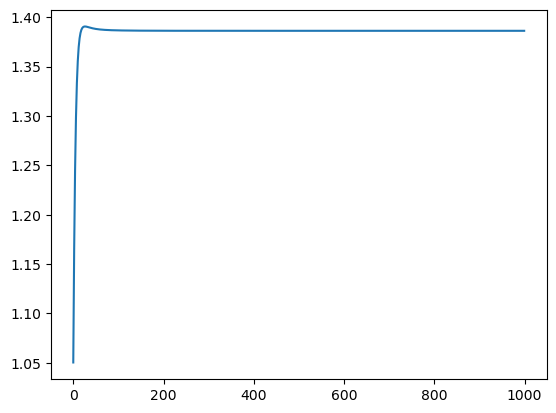

In [21]:
import matplotlib.pyplot as plt 
plt.plot(loss)

In [22]:
import pandas as pd
train_data=pd.read_csv(r"./mnist_train.csv")
test_data=pd.read_csv(r"./mnist_test.csv")

# Preprocessing the data
train_data=np.array(train_data.to_numpy())   # train_data shape: (60000, 785)
test_data=np.array(test_data.to_numpy())      # test_data shape: (10000, 785)

X_train=train_data[:,1:]            # X_train shape: (60000, 784)
y_train=train_data[:,0]             # y_train shape: (60000,)
X_test=test_data[:,1:]              # X_test shape: (10000, 784)
y_test=test_data[:,0]               # y_test shape: (10000,)

X_train = X_train / 255.0           # Normalizing the data
X_test = X_test / 255.0

def one_hot(y):
    one_hot_y = np.zeros((len(y),10))
    one_hot_y[np.arange(len(y)),y] = 1
    return one_hot_y

one_hot_y_train = one_hot(y_train)  # one_hot_y_train shape: (60000, 10)
one_hot_y_test = one_hot(y_test)    # one_hot_y_test shape: (10000, 10)


In [23]:
def accuracy(y_actual,y_train):
    return np.sum(np.argmax(y_actual,axis=1)==np.argmax(y_train,axis=1))/y_actual.shape[0]

In [24]:
class FFNN:
    def __init__(self,num_hidden_layers,inputs_nums:list,num_output,activations:list,loss_func:callable,lr=0.5) -> None:
        self.input = inputs_nums
        self.o = num_output
        self.layers = num_hidden_layers+2
        # self.w = [np.random.normal(0,np.sqrt(2/(self.input[i+1]+self.input[i])),(self.input[i+1],self.input[i])) for i in range(len(self.input)-1)]
        # self.b =[np.random.normal(0,np.sqrt(2/self.input[i+1]),(self.input[i+1],1)) for i in range(len(self.input)-1)]
        
        self.w = [np.random.random((self.input[i+1],self.input[i]))-0.5 for i in range(len(self.input)-1)]
        self.b = [np.random.random((self.input[i+1],1)) for i in range(len(self.input)-1)]
        
        self.activations = activations
        self.loss = []
        self.loss_func = loss_func
        self.lr = lr
        
    def forward(self,x,y):
        ## x.shape is (m,input[0])
        z=[x]*self.layers
        a=[x]*self.layers
        
        for i in range(1,self.layers):
            ## w[i-1].shape = (input[i],input[i-1])
            ## a1[i-1].shape = (m,input[i-1])
            assert(self.w[i-1].shape[1] == a[i-1].shape[1])
            z[i] = self.w[i-1]@a[i-1].T + self.b[i-1]
            a[i] = self.activations[i-1](z[i]).T
        
        return z,a
    
    def backward(self,x,y,z,a):
        m = a[0].shape[0]
        del_j=[None]*(self.layers-1)
        del_j[-1] = (a[-1] - y)
        ## del_j shape is (m,o)
        self.w[-1] -= self.lr*((del_j[-1]).T@a[-2])/m
        self.b[-1] -= self.lr*(np.sum(del_j[-1],axis=0)).reshape(-1,1)/m
        
        for i in range(self.layers-3,-1,-1):
            del_j[i] = (del_j[i+1]@self.w[i+1])*(a[i+1])*(1-a[i+1])
        

        for i in range(0,self.layers-2):
            self.w[i] -=  self.lr*(del_j[i].T@a[i])/m
            self.b[i] -= self.lr*(np.sum(del_j[i],axis=0)).reshape(-1,1)/m
        
    def train(self,x,y,epochs):
        for i in range(epochs): 
            z,a = self.forward(x,y)
            self.backward(x,y,z,a)
            self.loss.append(self.loss_func(y,a[-1]))
            acc = accuracy(y,a[-1])
            if(i%50 == 0):
                print(f"epoch {i} loss: {self.loss[i]:.2f} acc: {acc:.2f}")
        
    def test(self,x,y):
        z,a = self.forward(x,y)
        print(f"test accuracy {accuracy(y,a[-1])}")
        
    

In [25]:
print(X_train.shape)
nn = FFNN(1,[X_train.shape[1],20,10],10,[sigmoid,softmax],cel)

nn.train(X_train,one_hot_y_train,500)

(60000, 784)
epoch 0 loss: 154024.92 acc: 0.13
epoch 50 loss: 74175.83 acc: 0.69
epoch 100 loss: 49867.77 acc: 0.79
epoch 150 loss: 39085.35 acc: 0.83
epoch 200 loss: 33186.38 acc: 0.86
epoch 250 loss: 29500.22 acc: 0.87
epoch 300 loss: 26988.16 acc: 0.88
epoch 350 loss: 25165.78 acc: 0.89
epoch 400 loss: 23776.97 acc: 0.89
epoch 450 loss: 22675.50 acc: 0.89


In [44]:
nn.test(X_test,one_hot_y_test)

test accuracy 0.9008


In [4]:
x = np.array([
    [1,1],
    [1,0],
    [0,1],
    [0,0]
])
y = np.array(
   [[0],
    [1],
    [1],
    [0]]
)

xor = FFNN(1,[2,5,1],1,[sigmoid,sigmoid],cel)
xor.train(x,y,1500)

NameError: name 'np' is not defined

In [32]:
z,a = xor.forward(x,y)
a[-1]


array([[0.02322844],
       [0.98054973],
       [0.97713089],
       [0.02297963]])

In [6]:
# Generating n-bit numbers
def generate_n_bit_numbers(n):
    return [list(map(int, bin(i)[2:].zfill(n))) for i in range(2**n)]

x_2_list = generate_n_bit_numbers(2)
x_4_list = generate_n_bit_numbers(4)
x_5_list = generate_n_bit_numbers(5)

x_2 = np.array(x_2_list)
x_4 = np.array(x_4_list)
x_5 = np.array(x_5_list)

In [7]:
def palindrome_function(x):
    y = [int(seq == seq[::-1]) for seq in x]
    return y

# Even Parity function
def even_parity_function(x):
    y = [int(sum(seq) % 2 == 0) for seq in x]
    return y

In [8]:
x_4_palindrome_y = np.array(palindrome_function(x_4_list))
x_5_palindrome_y = np.array(palindrome_function(x_5_list))

x_4_even_parity_y = np.array(even_parity_function(x_4_list))
x_5_even_parity_y = np.array(even_parity_function(x_5_list))


In [26]:
pal_nn = FFNN(1,[4,5,1],1,[sigmoid,sigmoid],cel)
pal_nn.train(x_4,x_4_palindrome_y.reshape(-1,1),15000)

epoch 0 loss: 1.48 acc: 1.00
epoch 50 loss: 5.56 acc: 1.00
epoch 100 loss: 5.55 acc: 1.00
epoch 150 loss: 5.55 acc: 1.00
epoch 200 loss: 5.55 acc: 1.00
epoch 250 loss: 5.55 acc: 1.00
epoch 300 loss: 5.55 acc: 1.00
epoch 350 loss: 5.55 acc: 1.00
epoch 400 loss: 5.55 acc: 1.00
epoch 450 loss: 5.55 acc: 1.00
epoch 500 loss: 5.55 acc: 1.00
epoch 550 loss: 5.55 acc: 1.00
epoch 600 loss: 5.55 acc: 1.00
epoch 650 loss: 5.55 acc: 1.00
epoch 700 loss: 5.55 acc: 1.00
epoch 750 loss: 5.55 acc: 1.00
epoch 800 loss: 5.55 acc: 1.00
epoch 850 loss: 5.54 acc: 1.00
epoch 900 loss: 5.54 acc: 1.00
epoch 950 loss: 5.54 acc: 1.00
epoch 1000 loss: 5.54 acc: 1.00
epoch 1050 loss: 5.53 acc: 1.00
epoch 1100 loss: 5.52 acc: 1.00
epoch 1150 loss: 5.52 acc: 1.00
epoch 1200 loss: 5.51 acc: 1.00
epoch 1250 loss: 5.50 acc: 1.00
epoch 1300 loss: 5.48 acc: 1.00
epoch 1350 loss: 5.47 acc: 1.00
epoch 1400 loss: 5.45 acc: 1.00
epoch 1450 loss: 5.43 acc: 1.00
epoch 1500 loss: 5.40 acc: 1.00
epoch 1550 loss: 5.37 acc: 1.00

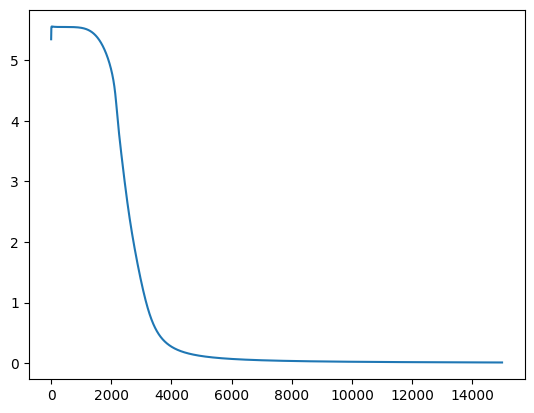

In [32]:
import matplotlib.pyplot as plt